<h1><center>IDATG2208 - Assignment 2</center></h1>

<h3><center>Introduksjon til maskinlæring</h3>

<p><center><strong>Bjørn Ivar Thorsen Høie</strong></center></p>

<p><center>NTNU Gjøvik</center></p>

<p><center>September 2026</center></p>


I would recommend to use the Github: https://github.com/BjornIvar1/IDATG2208-Assignment2/

## Exercise 1: Data Preparation

In [129]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.feature_selection import f_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xlrd.biffh import XL_SCL


adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

X = adult.data
y = adult.target

adult_data = pd.concat([X, y], axis=1)

In [130]:
# Split the data into 60% train and 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Split the data into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

stratified_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)

### Q1.1

In [131]:
# Create a variable for the missing values
missing_summary = pd.DataFrame({
    "Missing count": X_train.isna().sum(),
    "Missing percentage": X_train.isna().mean() * 100
})

# Prints only the missing values, amount and percentage
print(missing_summary[missing_summary["Missing count"] > 0])

                Missing count  Missing percentage
workclass                1667            5.688449
occupation               1677            5.722573
native-country            499            1.702781


There are 3 features where there is missing data, `workclass`, `occupation` and `native_country`. Looking at these we can check if workclass and occupation have a correlation or if it is just random, since they are in the same category.

In [132]:
print(pd.crosstab(X_train['workclass'].isna(), X_train['occupation'].isna()))

occupation  False  True 
workclass               
False       27628     10
True            0   1667


Looking at the crosstable there is 27628 people which both rows present. The crosstab shows 1667 rows missing both workclass and occupation simultaneously, and 10 people where workclass is present but occupation is missing. This overlap shows the two missingness patterns are not independent, but they share the same underlying cause rather than being two separate random processes.

In [133]:
# Retrieve the workclass, for the 10 people
print(X_train[(X_train['workclass'].notna()) & (X_train['occupation'].isna())]['workclass'].value_counts())

workclass
Never-worked        10
Federal-gov          0
Local-gov            0
Private              0
Self-emp-inc         0
Self-emp-not-inc     0
State-gov            0
Without-pay          0
Name: count, dtype: int64


Looking further in the 10 people with a workclass and not an occupation, they are listed in the sub-group `Never-worked`. This suggest that the missing occupation values are not random.

I would use imputation for the missing data. Since the only features which are missing is categorical data i would label them as unknown. This helps preserve observations and subgroups, for example removing the people under `Never-worked` category it would mean that a subgroup of people would be lost. I prefer this implementation over most frequent imputation because assigning the most common category would create incorrect information and the data would be unreliable. One risk of using this strategy is that the model may rely to much on the unknown data and take shortcuts.

### Q1.2

Lower age limit: -2.0
Upper age limit: 78.0
Q1 = 28.0, Q3 = 48.0, IQR = 20.0
Number of outliers: 131


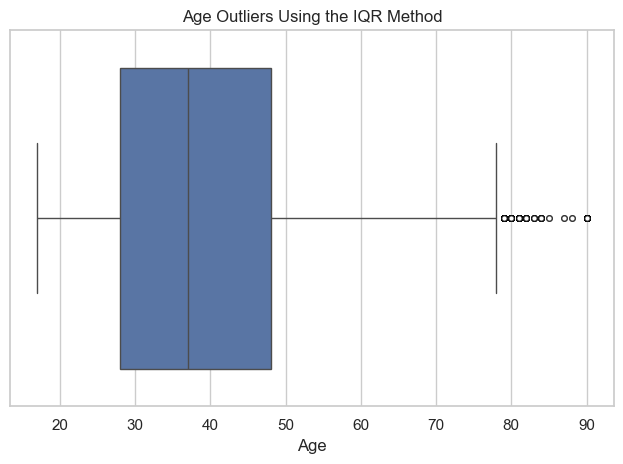

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

X_train_age = X_train["age"]

# Calculate Q1, Q3 and IQR
Q1 = X_train_age.quantile(0.25)
Q3 = X_train_age.quantile(0.75)
IQR = Q3 - Q1

# Define the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower age limit:", lower_bound)
print("Upper age limit:", upper_bound)

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")

# Detect the outliers
iqr_Outliers = ((X_train_age < lower_bound) | (X_train_age > upper_bound))

print(f"Number of outliers: {iqr_Outliers.sum()}")

# Plot of the outliers using IQE
plt.style.use("default")
sns.set_theme(style="whitegrid")

sns.boxplot(
    x=X_train_age,
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "alpha": 0.6
    }
)

plt.xlabel("Age")
plt.title("Age Outliers Using the IQR Method")
plt.tight_layout()
plt.show()

Number of outliers = 109
Lower age limit: -2.519208908300641
Upper age limit: 79.9073679255332


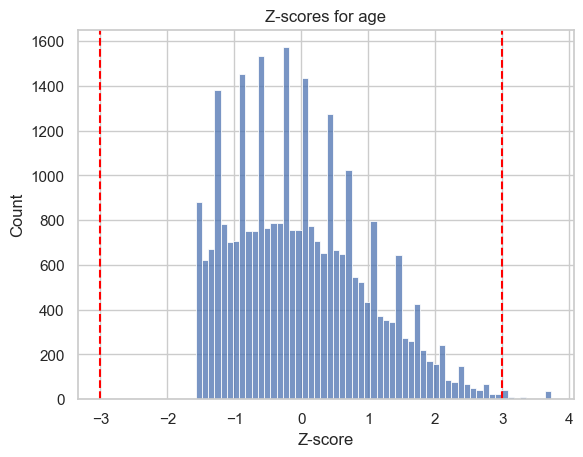

In [135]:
# Calculate z score
age_mean = X_train_age.mean()
age_std = X_train_age.std()
age_z_scores = (X_train_age-age_mean)/age_std

z_score_outliers = age_z_scores.abs() > 3

print(f"Number of outliers = {z_score_outliers.sum()}")

# Bound value
print("Lower age limit:", age_mean - 3 * age_std)
print("Upper age limit:", age_mean + 3 * age_std)

# Simple plot
sns.histplot(age_z_scores)

plt.axvline(-3, color="red", linestyle="--")
plt.axvline(3, color="red", linestyle="--")

plt.xlabel("Z-score")
plt.title("Z-scores for age")
plt.show()

The IQR method flags 131 outliers for the age feature, whereas the z-scores only flags 109 outliers. The bounds for the two methods are different both use a lower bound around $-2$ which does not affect the data since its not a valid age. The upper boundary for IQR is $78.0$ and for z-score $79.90$, which explains why IQR have more outliers then z_score. To justify whether we should keep, remove or cap them we have to consider what these people represent for the prediction. I would keep the observations because age above these boundarise are still valid and do not necessarily represent errors in the data. Removing and capping them would mean we would loose valubale information for an age group. Tree-based models are generally not strongly affected by outliers because they split the data using threshold, but SVMs are more sensitive. This is because extreme values can affect the distance between observaions and the decision boundary.

### Q1.3

In [136]:
# Get the unique features category
print(X_train.select_dtypes(include=['object', 'category']).nunique(
    dropna=False
).sort_values(ascending=False))

native-country    42
education         16
occupation        15
workclass          9
marital-status     7
relationship       6
race               5
sex                2
dtype: int64


The feature `native-country` have 42 distinct categories. It would be an idea to use frequency thresholding, because there are several countries that occur rarely. These catagories provide little information and may cause overfitting.

In [137]:
print(f"Unique countries: {X_train["native-country"].value_counts()}")

Unique countries: native-country
United-States                 26298
Mexico                          584
Philippines                     187
Germany                         124
Puerto-Rico                     111
Canada                          104
El-Salvador                      87
Cuba                             82
England                          80
India                            79
South                            75
China                            69
Jamaica                          63
Vietnam                          58
Italy                            57
Guatemala                        56
Japan                            54
Dominican-Republic               52
Columbia                         49
Haiti                            48
Poland                           47
Portugal                         43
Iran                             38
Taiwan                           37
Peru                             31
Nicaragua                        30
Greece                         

Eg. Holand-Netharlands are only counted once, while we have USA counted 26298 times. Here it would be a good idea to use frequncy thersholding and replace cateogries with a new category "other". I will try to use a threshold of $0.1\%$ and see if how it looks.

In [138]:
countries_count = X_train["native-country"].value_counts(normalize=True)
rare_countries = countries_count[countries_count < 0.001].index

country_example = (
    X_train["native-country"]
    .astype("object")
    .replace(rare_countries, "Other")
)

print(country_example.value_counts())
print("Unique countries:", country_example.nunique())

native-country
United-States         26298
Mexico                  584
Other                   234
Philippines             187
Germany                 124
Puerto-Rico             111
Canada                  104
El-Salvador              87
Cuba                     82
England                  80
India                    79
South                    75
China                    69
Jamaica                  63
Vietnam                  58
Italy                    57
Guatemala                56
Japan                    54
Dominican-Republic       52
Columbia                 49
Haiti                    48
Poland                   47
Portugal                 43
Iran                     38
Taiwan                   37
Peru                     31
Nicaragua                30
Greece                   29
Name: count, dtype: int64
Unique countries: 28


This reduced unique countries from 42 distinct groups to 28, while creating a new group called `Others` with a count of 234. I used the threshold $0.1\%$, sicne countries below this threshold provide little data compared to the other groups. This also helps reduce overfitting, and the new catagory contains more obsercations than each rare country did individually making it a more reliable category.

### Q1.4

In [139]:
categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_data = encoder.fit_transform(
    X_train[categorical_features]
)

encoded_X_train = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)

final_X_train = pd.concat(
    [
        X_train.drop(columns=categorical_features),
        encoded_X_train
    ],
    axis=1
)

print("Shape before encoding:", X_train.shape)
print("Shape after encoding:", final_X_train.shape)
print(final_X_train.head())

Shape before encoding: (29305, 14)
Shape after encoding: (29305, 108)
       age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week  \
47291   18  225859             10          2907             0              30   
25800   31  454508              7             0          2001              40   
44902   34  118551             13             0             0              35   
41893   59  145574              7             0             0              40   
16531   41  112763             15             0             0              40   

       workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  \
47291                    0.0                  0.0                     0.0   
25800                    0.0                  0.0                     0.0   
44902                    0.0                  0.0                     0.0   
41893                    0.0                  0.0                     0.0   
16531                    0.0                  0.0         

I used one hot encoding for work
- workclass
- education
- marital-status
- occupation
- relationship
- race
- sex
- native-country

One hot encoding converts these categories into binary columns containging either 0 or 1. `natice-country` is divided into columns such as `native-country-united-states` and `natice-country_vietnam`. The number of features increased from 14 to 108. As shown in Q1.3 grouping rare countries into an `other` can reduce the number of columns.

### Q1.5

sex_Female                         sex_Male                             1.000000
sex_Male                           sex_Female                           1.000000
workclass_nan                      occupation_nan                       0.996834
occupation_nan                     workclass_nan                        0.996834
marital-status_Married-civ-spouse  relationship_Husband                 0.893830
relationship_Husband               marital-status_Married-civ-spouse    0.893830
race_White                         race_Black                           0.789399
race_Black                         race_White                           0.789399
marital-status_Married-civ-spouse  marital-status_Never-married         0.642924
marital-status_Never-married       marital-status_Married-civ-spouse    0.642924
dtype: float64


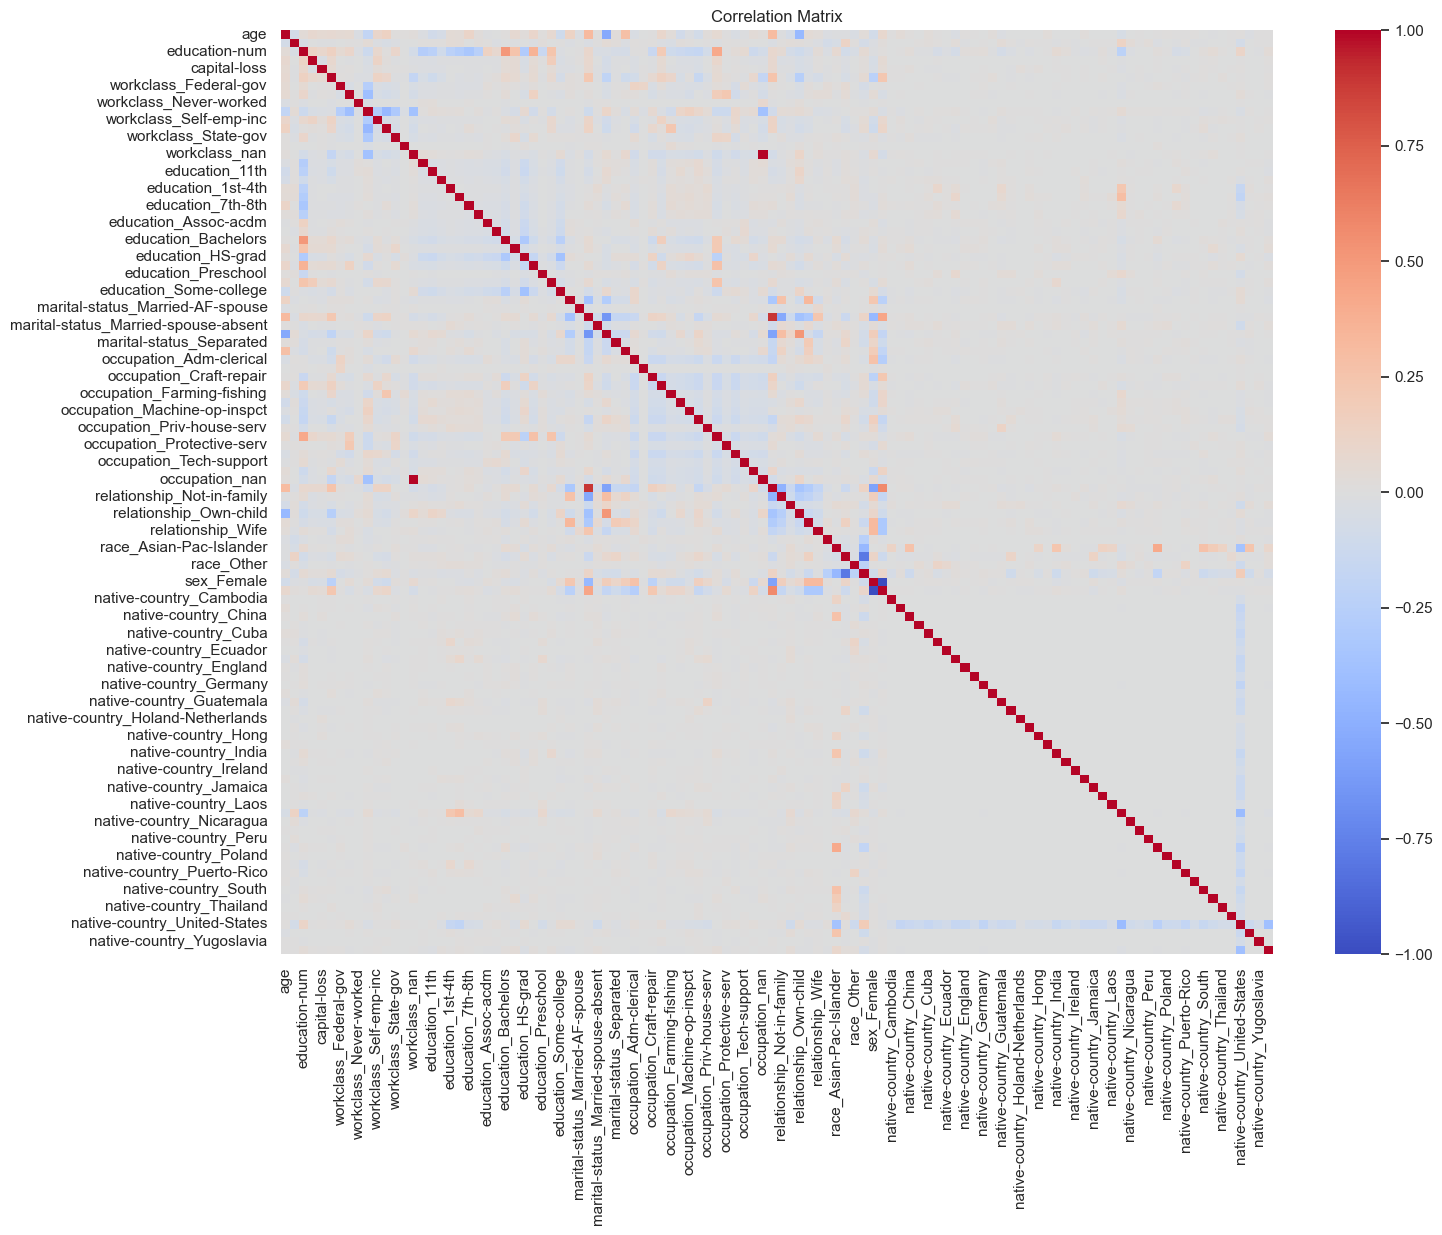

In [140]:
corr_matrix = final_X_train.corr()

unstack_corr = corr_matrix.abs().unstack()
sorted_corr = unstack_corr.sort_values(ascending=False)
topp_corr = sorted_corr[sorted_corr < 1]
print(topp_corr.head(10))

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

sex_Female and sex_Male have a perfect negative correlation of $-1$, it says $1$ but we used `abs()` which made it $1$ and not $-1$.
```
sex_Female | sex_Male   | -1.000000
sex_Male   | sex_Female | -1.000000
```
This makes sense because they contain opposite information: if sex_Male i 1, then sex_Female must be 0, and vice versa. The absolute correlation matrix displays this as 1.

```
workclass_nan | occupation_nan | 0.996834
```
From the crosstable created in Q1.1 we found out that if worclass is empty than and occupation is probably empty aswell, but there are outliers which had worcklass and not an occupation which explains the correlation value to be $0.995834$.

Multicollinearity is a concern for SVM because strongly correlated features may contain similar information which may give to much influence when the model creates its decision boundary. A decision tree is less affected because it consider one feature at a time when creating the splits. If two features contain similar information a decision tree may ignore one over the other.


### Q1.6

In [141]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

y_train_encoded = LabelEncoder().fit_transform(y_train.astype(str))

chi_square_result = []

#Cramer V
for feature in categorical_features:
    feature_values = (
        X_train[feature].astype("object").fillna("Missing")
    )

    contingency_table = pd.crosstab(
        feature_values,
        y_train_encoded
    )

    chi2, p_value, degrees_freedom, expected = (
        chi2_contingency(contingency_table)
    )

    n = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(rows - 1, columns - 1))
    )

    chi_square_result.append({
        "Feature": feature,
        "p-value": p_value,
        "Cramers V": cramers_v,
        "Significant": p_value < 0.05
    })

chi_square_results = pd.DataFrame(
    chi_square_result
).sort_values("p-value", ascending=True)

The catagorical features with the strongest associations are relationship, martial-status, education and occuaption.

In [142]:
numerical_features = X_train.select_dtypes(include="number").columns

X_train_numerical = X_train[numerical_features].copy()

f_values, p_values = f_classif(
    X_train_numerical,
    y_train_encoded
)

# Calculate eta sqaured
number_of_classes = len(np.unique(y_train_encoded))
df_between = number_of_classes - 1
df_within = len(y_train_encoded) - number_of_classes

eta_squared = ((f_values * df_between) /
               (f_values * df_between + df_within))

anova_results = pd.DataFrame({
    "Feature": numerical_features,
    "p-value": p_values,
    "Eta sqaured": eta_squared,
    "Significant": p_values < 0.05
})

In [143]:
print("Chi square result:")
print(chi_square_results.head(8))

print("\nANOVA results:")
print(
    anova_results
    .sort_values("p-value", ascending=True)
    .head(8)
    .to_string(index=False)
)

Chi square result:
          Feature        p-value  Cramers V  Significant
1       education   0.000000e+00   0.362735         True
2  marital-status   0.000000e+00   0.451593         True
3      occupation   0.000000e+00   0.350446         True
4    relationship   0.000000e+00   0.457087         True
6             sex  7.884834e-303   0.217284         True
0       workclass  1.202157e-198   0.179559         True
5            race   1.252160e-67   0.104211         True
7  native-country   1.117039e-35   0.096176         True

ANOVA results:
       Feature       p-value  Eta sqaured  Significant
           age  0.000000e+00     0.052940         True
 education-num  0.000000e+00     0.109391         True
hours-per-week  0.000000e+00     0.052108         True
  capital-gain 1.100823e-311     0.047444         True
  capital-loss 9.831035e-151     0.023067         True
        fnlwgt  2.854103e-01     0.000039        False


I used chi sqaure for the categorical features and ANOVA F for the numerical values, and a significance level of 0.05. The top eight features were relationship, marital-status, education, occupation, education-num, age, hours-per-week and capital-gain. I expect many of these features to be imporant in exercise 2 becayse income is probably connected to education, age, hours-per-week.

### Q1.7

In [144]:
from sklearn.preprocessing import StandardScaler

# Standardize the numerical features
x_standardized = StandardScaler().fit_transform(X_train[numerical_features])

# Print before and after standardization
print("Orignal mean: \n", X_train[numerical_features].mean())
print("\nOrignal std: \n", X_train[numerical_features].std())
print("\nNew means: \n", x_standardized.mean(axis=0))
print("\nNew std: \n", x_standardized.std(axis=0))

Orignal mean: 
 age                   38.694080
fnlwgt            189412.169459
education-num         10.081829
capital-gain        1006.890189
capital-loss          88.925269
hours-per-week        40.444327
dtype: float64

Orignal std: 
 age                   13.737763
fnlwgt            104456.390541
education-num          2.567328
capital-gain        6995.439728
capital-loss         406.656879
hours-per-week        12.445617
dtype: float64

New means: 
 [ 4.97052588e-17 -2.47313970e-17  1.10563893e-16 -2.17005886e-17
  1.11533751e-17  1.18807692e-16]

New std: 
 [1. 1. 1. 1. 1. 1.]


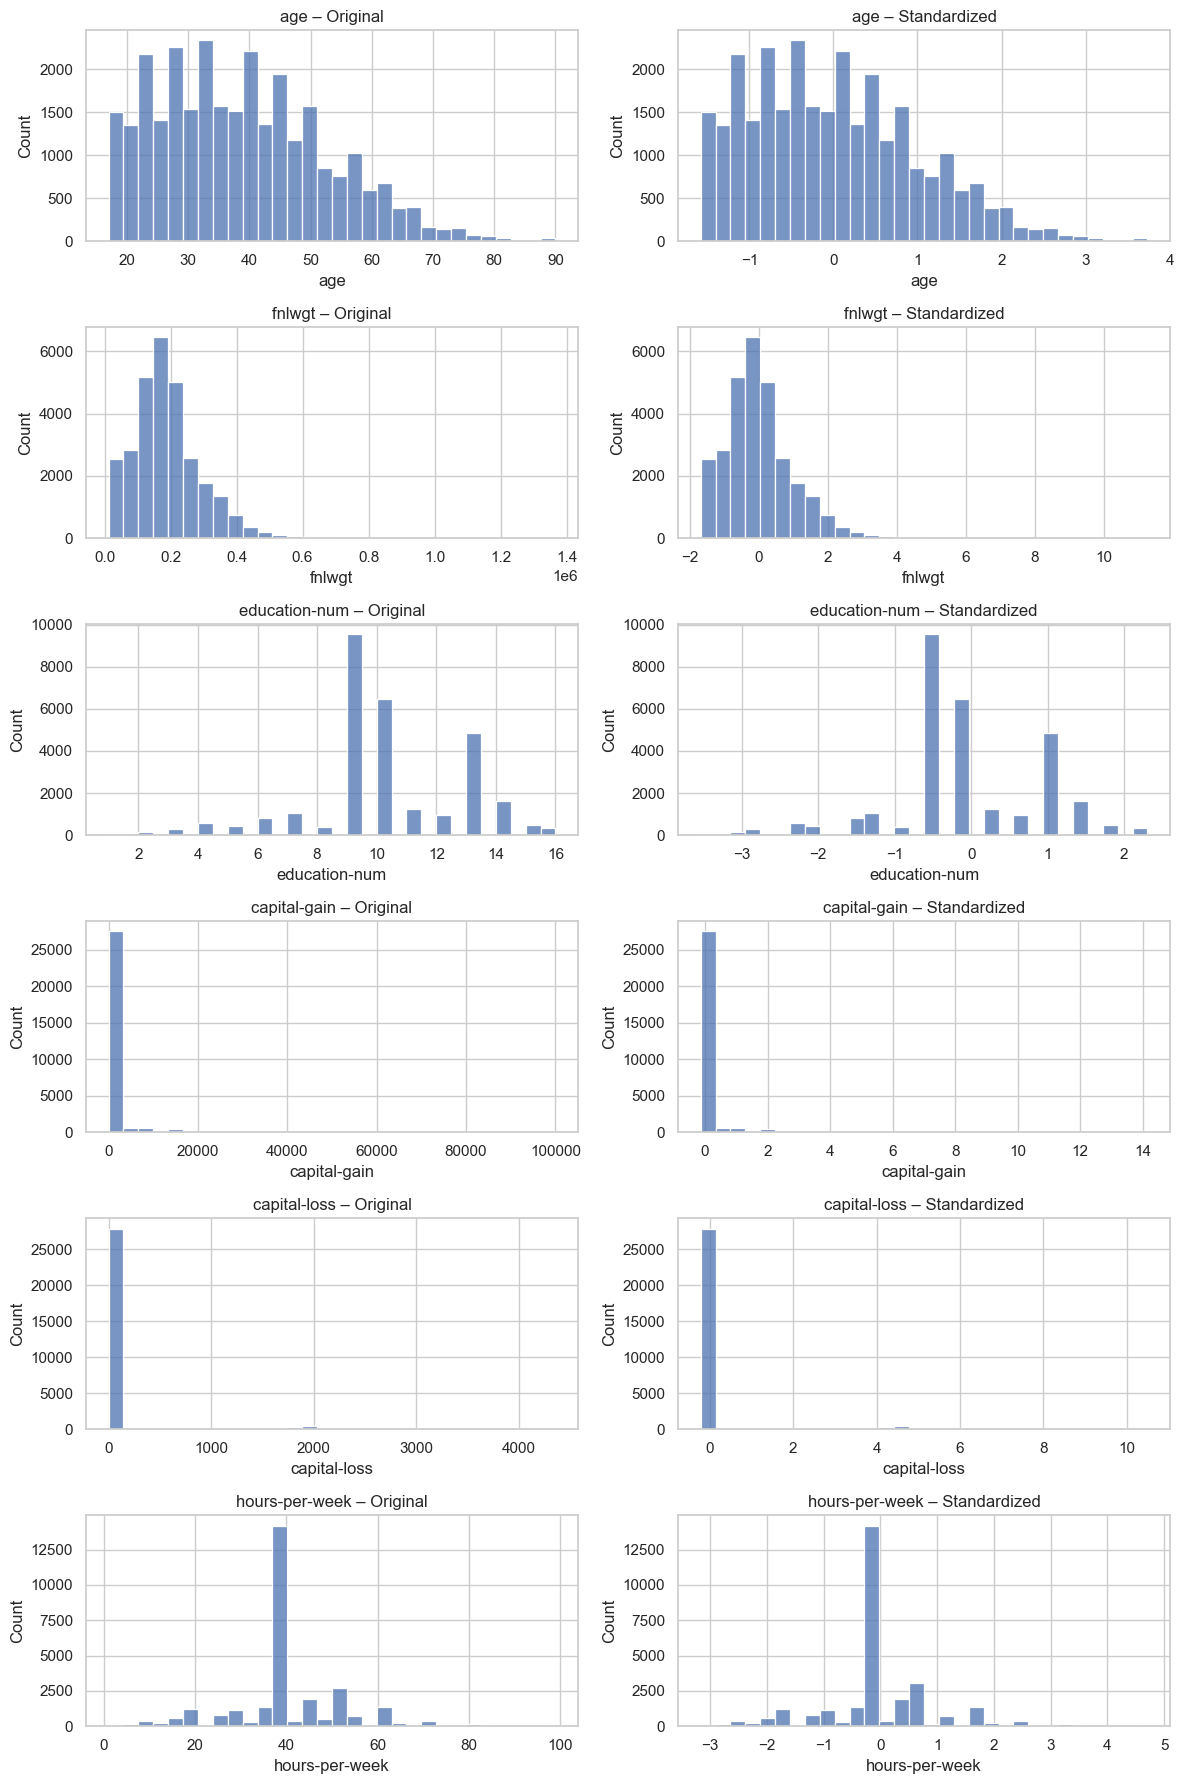

In [145]:
# plot before and after standardization
standardized_df = pd.DataFrame(
    x_standardized,
    columns=numerical_features,
    index=X_train.index
)

fig, axes = plt.subplots(
    nrows=len(numerical_features),
    ncols=2,
    figsize=(12, 18)
)

for row, feature in enumerate(numerical_features):
    # Original distribution
    sns.histplot(
        X_train[feature],
        bins=30,
        ax=axes[row, 0]
    )
    axes[row, 0].set_title(
        f"{feature} – Original"
    )
    # Standardized distribution
    sns.histplot(
        standardized_df[feature],
        bins=30,
        ax=axes[row, 1]
    )

    axes[row, 1].set_title(
        f"{feature} – Standardized"
    )

plt.tight_layout()
plt.show()

Before standardization, the numercal features had different means and std. `fnlwgt` had larger values compared to `age` or `hours-per-week`. After standardization every numverical feature had a mean close to 0 and a std close to 1. Having every feature in the same scale is imporant for SVM since there larger values can dominate the distance calulations. Decision trees  are not affect in the same way since it split features using threhsolds.

### Q1.8

In [146]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Pipeline for nuemrical features only standardize it
numerical_pipeline = Pipeline([
    (
        "standardization",
        StandardScaler()
    )
])

# Pipeline for categorical features,
# replace missing features, group rare categories
# and one hot encode
categorical_pipeline = Pipeline([
    (
        "missing_values",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            min_frequency=0.001,
            handle_unknown="infrequent_if_exist"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

I used `Pipeline` to create two different pipelines, one for the numerical features and one for the categorical features. Then i used `ColumnTransformer` to combine the two pipelines. The numerical features are standardized, and i decided to keep the outliers. For example the age outliers were still valid data even if they were outliers they represented valid information.

For the categorical features I decided to replace the missing values with a new category "Missing". Then the pipeline use one hot encoding and converts the categories into binary columns, and categories representing less than 0.1% of the training data are grouped into an infrequent category.

The preprocessor is fitted only on `X_train`, and for `X_val` and `X_test` it is only transformed and not fitted. This will prevent information from the datasets to influence the preprocessing.

For example, if StandardScaler were fitted before splitting the dataset, the mean and std would include ages from the validation and test sets. Then the model will contain information from data that its not supposed to have seen, and we are supposed to use the training data for this. Using the full dataset for determine which countries that occur less than 0.1% can change which countries are grouped as infrequent. This would cause data leakage and make the evaluation less reliable.

### Q1.9

In [147]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

class
<=50K    37155
>50K     11687
Name: count, dtype: int64
class
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


Three way stratification separates every split so they can do their own distinct jobs. The training set is used to train the model and perform a five fold crossvalidation. The validation set is used to compare the models and select the hyperparameters. While the test set is kept separate and is only used for the final evaluation. This is done so that the model cant adjust itself to match the data from the test set, making the predictions unreliable.

The dataset has two types of income classes, above 50K and under 50K. The two income classes are imbalanced because 76% of the observations belong to the under 50K class, while only 24% belong to the above 50K class. Stratification ensures that the same ratio of observations is split in training, validation and the test set. This prevents one split from containing to few observations for one income class, which would make the prediction less reliable.

Five fold cross validation also makes it more robust because the model is evaluated on several different split instead of only one split.

## Exercise 2: Decision Trees

### Q2.1

In [148]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Decision Tree with default parameters
dtc = Pipeline([
    ("preprocessor", preprocessor),
    ("decision_tree", DecisionTreeClassifier(random_state=42))
])

# Add 5-fold stratified cross validation on the training set
q24_results = cross_validate(dtc, X_train, y_train, cv=stratified_cv,
                             scoring=["accuracy", "balanced_accuracy"])


print("Cross Validation results")
print("Accuracy (mean and std):", q24_results["test_accuracy"].mean(), "+/-", q24_results["test_accuracy"].std())
print("Balanced Accuracy (mean and std):", q24_results["test_balanced_accuracy"].mean(), "+/-", q24_results["test_balanced_accuracy"].std())

# Fit the training set, and evaluate using the validation set
dtc.fit(X_train, y_train)
y_val_pred = dtc.predict(X_val)

print("\nValidation results")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred))

Cross Validation results
Accuracy (mean and std): 0.8113291247227435 +/- 0.005081363876782473
Balanced Accuracy (mean and std): 0.7459771471005632 +/- 0.0060227040066904765

Validation results
Accuracy: 0.814086814086814
Balanced Accuracy: 0.7496250053336222


The cross validation has an mean accuracy of approximately $0.8113$ and a std of $\pm0.0050$, and balanced accuracy mean of $0.7459$ and a std of $\pm0.006$.

The validation result has an accuracy of $0.8140$, and a balanced accuracy of $0.7496$.

### Q2.2

In [149]:
dtc_importance = dtc.named_steps["decision_tree"].feature_importances_
dtc_feat_names = dtc.named_steps["preprocessor"].get_feature_names_out()

ranked_dtc_features = sorted(
    zip(dtc_feat_names, dtc_importance),
    key=lambda x: x[1],
    reverse=True
)

for f, i in ranked_dtc_features[:5]:
    print(f"{f}: {i:.5f}")

categorical__marital-status_Married-civ-spouse: 0.20132
numerical__fnlwgt: 0.18739
numerical__age: 0.11142
numerical__education-num: 0.10687
numerical__capital-gain: 0.09986


The top 5 features are:
 - `categorical__marital-status_Married-civ-spouse`
 - `numerical__fnlwgt`
 - `numerical__age`
 - `numerical__education-num`
 - `numerical__capital-gain`

Features such as age, education number and capital gain are reasonable predictors because they give information about a person. For example better education may give access to higher paying jobs. Martial status does not directly determine a persons income. Its high importance can be explained because it is often associated with other factors, such as age, household situation and employment, rather than because marriage itself causes higher income. The feature importance of fnlwgt was surprising because it reflects sampling design and does not give information about a person earning power.

### Q2.3

In [150]:
from sklearn.metrics import f1_score, make_scorer

q23_results = []

# Define >50K as the positive class
f1_scorer = make_scorer(
    f1_score,
    pos_label=">50K"
)

# Decision Tree with varied depth
for depth in range(2, 16):
    dtc_depth = Pipeline([
        ("preprocessor", preprocessor),
        ("decision_tree", DecisionTreeClassifier(random_state=42, max_depth=depth))
    ])

    # Five fold CV
    cv_depth_results = cross_validate(
        dtc_depth,
        X_train,
        y_train,
        cv=stratified_cv,
        scoring={"accuracy": "accuracy", "f1": f1_scorer}
    )

    # Fit the model on the training set
    dtc_depth.fit(X_train, y_train)

    # Predict training and validation
    y_train_pred = dtc_depth.predict(X_train)
    y_val_pred = dtc_depth.predict(X_val)

    # Store the results
    q23_results.append({
        "Max Depth": depth,
        "CV Accuracy Mean": cv_depth_results["test_accuracy"].mean(),
        "CV Accuracy Std": cv_depth_results["test_accuracy"].std(),
        "CV F1 Mean": cv_depth_results["test_f1"].mean(),
        "CV F1 Std": cv_depth_results["test_f1"].std(),
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Val Accuracy": accuracy_score(y_val, y_val_pred),
        "Val F1":
            f1_score(
                y_val,
                y_val_pred,
                pos_label=">50K"
            )
    })

results_df = pd.DataFrame(q23_results)
print(results_df.to_string(index=False))

 Max Depth  CV Accuracy Mean  CV Accuracy Std  CV F1 Mean  CV F1 Std  Train Accuracy  Val Accuracy   Val F1
         2          0.828050         0.002769    0.567114   0.011947        0.828630      0.829648 0.571796
         3          0.841768         0.003632    0.615356   0.014644        0.842177      0.843776 0.621152
         4          0.842484         0.003487    0.618809   0.014845        0.842177      0.843776 0.621152
         5          0.846340         0.003116    0.618910   0.016723        0.845794      0.846233 0.618200
         6          0.851800         0.002108    0.634373   0.007254        0.855281      0.856368 0.651255
         7          0.853233         0.001845    0.642367   0.011304        0.858318      0.858108 0.654192
         8          0.854155         0.003406    0.648328   0.021998        0.862515      0.858313 0.667627
         9          0.854462         0.004689    0.667342   0.013063        0.866507      0.860463 0.669736
        10          0.854257

I tested the depths from 2 to 15 and selected depth 9 as the best depth to use. It had a cross validation accuracy of $0.854462\pm0.004689$, CV F1 Mean of $0.667342\pm0.013063$, a cross-validation F1-score of $0.6673 \pm 0.0131$, a validation accuracy of 0.860463 and a validation F1-score of $0.669736$. The training accuracy was $0.866507$, giving a small training–validation gap of $0.006044$.

The lower depths underfit the model because their training and validation score were relatively low. After depth 9 the training accuracy continued to increase but the validation accuracy decreased. Thats why I chose depth 9, since I belive it has a good balance between underfitting and overfitting the data.

### Q2.4

In [151]:
leaf_results = []

leaf_values = [1, 2, 5, 10, 20, 50, 100]

# Decision Tree with varied depth
for leaf in leaf_values:
    dtc_leaf = Pipeline([
        ("preprocessor", preprocessor),
        ("decision_tree", DecisionTreeClassifier(random_state=42, min_samples_leaf=leaf))
    ])

    # Five fold CV
    cv_depth_results = cross_validate(
        dtc_leaf,
        X_train,
        y_train,
        cv=stratified_cv,
        scoring={"accuracy": "accuracy", "f1": f1_scorer}
    )

    # Fit the model on the training set
    dtc_leaf.fit(X_train, y_train)

    # Predict training and validation
    y_train_pred = dtc_leaf.predict(X_train)
    y_val_pred = dtc_leaf.predict(X_val)

    # Store the results
    leaf_results.append({
        "Leaf Value": leaf,
        "CV Accuracy Mean": cv_depth_results["test_accuracy"].mean(),
        "CV Accuracy Std": cv_depth_results["test_accuracy"].std(),
        "CV F1 Mean": cv_depth_results["test_f1"].mean(),
        "CV F1 Std": cv_depth_results["test_f1"].std(),
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Val Accuracy": accuracy_score(y_val, y_val_pred),
        "Val F1":
            f1_score(
                y_val,
                y_val_pred,
                pos_label=">50K"
            )
    })

leaf_results_df = pd.DataFrame(leaf_results)
print(leaf_results_df.to_string(index=False))

 Leaf Value  CV Accuracy Mean  CV Accuracy Std  CV F1 Mean  CV F1 Std  Train Accuracy  Val Accuracy   Val F1
          1          0.811329         0.005081    0.611559   0.009315        0.999966      0.814087 0.617039
          2          0.823545         0.002750    0.612138   0.007251        0.958164      0.820536 0.604021
          5          0.830131         0.002555    0.628785   0.004536        0.917761      0.832105 0.633438
         10          0.840812         0.003116    0.639842   0.008998        0.891861      0.845618 0.653014
         20          0.848456         0.002860    0.650059   0.006465        0.876779      0.850020 0.660801
         50          0.852312         0.003478    0.660048   0.007206        0.866337      0.853092 0.659549
        100          0.849957         0.002530    0.648280   0.011310        0.860126      0.856572 0.664431


In [152]:
alpha_results = []

alpha_values = [0.0, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]

# Decision Tree with varied depth
for alpha in alpha_values:
    dtc_alpha = Pipeline([
        ("preprocessor", preprocessor),
        ("decision_tree", DecisionTreeClassifier(random_state=42, ccp_alpha=alpha))
    ])

    # Five fold CV
    cv_depth_results = cross_validate(
        dtc_alpha,
        X_train,
        y_train,
        cv=stratified_cv,
        scoring={"accuracy": "accuracy", "f1": f1_scorer}
    )

    # Fit the model on the training set
    dtc_alpha.fit(X_train, y_train)

    # Predict training and validation
    y_train_pred = dtc_alpha.predict(X_train)
    y_val_pred = dtc_alpha.predict(X_val)

    # Store the results
    alpha_results.append({
        "Alpha Value": alpha,
        "CV Accuracy Mean": cv_depth_results["test_accuracy"].mean(),
        "CV Accuracy Std": cv_depth_results["test_accuracy"].std(),
        "CV F1 Mean": cv_depth_results["test_f1"].mean(),
        "CV F1 Std": cv_depth_results["test_f1"].std(),
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Val Accuracy": accuracy_score(y_val, y_val_pred),
        "Val F1":
            f1_score(
                y_val,
                y_val_pred,
                pos_label=">50K"
            )
    })

alpha_results_df = pd.DataFrame(alpha_results)
print(alpha_results_df.to_string(index=False))

 Alpha Value  CV Accuracy Mean  CV Accuracy Std  CV F1 Mean  CV F1 Std  Train Accuracy  Val Accuracy   Val F1
      0.0000          0.811329         0.005081    0.611559   0.009315        0.999966      0.814087 0.617039
      0.0001          0.855827         0.004748    0.672759   0.011387        0.875994      0.863636 0.685552
      0.0005          0.854666         0.001848    0.659056   0.009754        0.857089      0.856982 0.662316
      0.0010          0.851049         0.003023    0.640083   0.016302        0.854564      0.854320 0.651311
      0.0020          0.845862         0.002541    0.630540   0.010826        0.846238      0.847359 0.635720
      0.0050          0.841699         0.003615    0.615323   0.014532        0.842041      0.843776 0.621152
      0.0100          0.841699         0.003615    0.615323   0.014532        0.842041      0.843776 0.621152
      0.0200          0.819655         0.002957    0.535170   0.011438        0.820235      0.821867 0.543067


The best leaf value to use was `min_sample_leaf=100`. It reached a validation accuracy of $0.856572$, F1 validaiton of $0.6644$ and the train validation gap was $0.8601−0.8566=0.0035$.

The best alpha value to use was `ccp_alpha=0.0001`. It reached a validation accuracy of $0.8636$, F1 validaiton of $0.6856$ and the train validation gap was $0.8760−0.8636=0.0124$.

Comparing them, the `ccp_alpha=0.0001` generalised best because it got the highest validation accuracy and F1 score.

### Q2.5

In [153]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

q25_results = []

for model_name, weight in [
    ("Unweighted", None),
    ("Balanced", "balanced")
]:

    dtc_weight = Pipeline([
        ("preprocessor", preprocessor),
        (
            "decision_tree",
            DecisionTreeClassifier(
                random_state=42,
                class_weight=weight
            )
        )
    ])

    dtc_weight.fit(X_train, y_train)
    y_val_pred = dtc_weight.predict(X_val)

    q25_results.append({
        "Model": model_name,
        "Precision": precision_score(
            y_val,
            y_val_pred,
            pos_label=">50K"
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred,
            pos_label=">50K"
        ),
        "F1": f1_score(
            y_val,
            y_val_pred,
            pos_label=">50K"
        )
    })

q25_results_df = pd.DataFrame(q25_results)
print(q25_results_df.to_string(index=False))

     Model  Precision   Recall       F1
Unweighted   0.608316 0.626016 0.617039
  Balanced   0.617903 0.637997 0.627789


The balanced Decision Tree performed better for the minority $>50K$ class. Precision increased from $0.6083$ to $0.6179$, recall from $0.6260$ to $0.6380$, and F1-score from $0.6170$ to $0.6278$.

This matters because fewer people earn more than $50K$. Without class weighting, the tree may pay more attention to the larger $<=50K$ class. Setting `class_weight="balanced"` gives errors on the minority class more weight during training. In this experiment, that improved all three reported scores.


## Exercise-3: Support Vector Machine

### Q3.1

Fold 1 validation accuracy: 0.851965601965602
Fold 2 validation accuracy: 0.8544226044226044
Fold 3 validation accuracy: 0.8516584766584766
Fold 4 validation accuracy: 0.8526822276822277
Fold 5 validation accuracy: 0.8535012285012284
Linear Accuracy: 0.8528460278460278 +/- 0.0010126341538802819
Linear F1: 0.6560445091967608 +/- 0.004595296972830089
Linear ROC-AUC: 0.9024143212980906 +/- 0.0006192669207336719


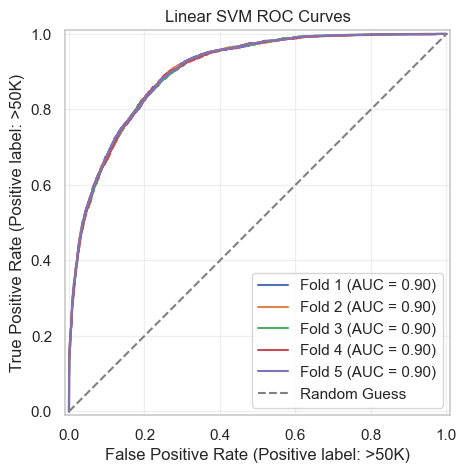

In [154]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay

# training subsample
X_svm, _, y_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size = 10000,
    stratify=y_train,
    random_state=42
)

q31_accuracy_results = []
q31_f1_results = []
q31_auc_results = []

fig, ax = plt.subplots(figsize=(7, 5))

for fold, (train_index, _) in enumerate(stratified_cv.split(X_svm, y_svm)):
    X_fold_train = X_svm.iloc[train_index]
    y_fold_train = y_svm.iloc[train_index]

    linear_svm = Pipeline([
        ("preprocessor", preprocessor),
        ("svm", SVC(kernel="linear"))
    ])

    # Train using the folds observations
    linear_svm.fit(X_fold_train, y_fold_train)

    # Evaluate and predict
    y_val_pred = linear_svm.predict(X_val)
    y_val_score = linear_svm.decision_function(X_val)

    q31accuracy_score = accuracy_score(y_val, y_val_pred)

    q31_accuracy_results.append(q31accuracy_score)

    q31_f1_results.append(
        f1_score(
            y_val,
            y_val_pred,
            pos_label=">50K"
        )
    )

    q31_auc_results.append(
        roc_auc_score(
            y_val == ">50K",
            y_val_score
        )
    )

    print("Fold", fold+1, "validation accuracy:", accuracy_score(y_val, y_val_pred))

    # Plot validation ROC curve for this folds model
    RocCurveDisplay.from_estimator(
        linear_svm,
        X_val,
        y_val,
        pos_label=">50K",
        name=f"Fold {fold + 1}",
        ax=ax
    )

print("Linear Accuracy:", np.mean(q31_accuracy_results), "+/-", np.std(q31_accuracy_results))
print("Linear F1:", np.mean(q31_f1_results), "+/-", np.std(q31_f1_results))
print("Linear ROC-AUC:", np.mean(q31_auc_results), "+/-", np.std(q31_auc_results))

# Plot
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("Linear SVM ROC Curves")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.show()

The linear SVM achived a mean validation accuracy of $0.8528$ and a STD accuracy of $0.0010$ across the 5 folds, and all five ROC curves overlap almost the same with an AUC $\approx 0.9$, which indicates the model is stable regardless of the subsample of training rows it was fit on. The sample size of $10000$ was large enough to give a representative training sample despite it not using the full training set.

### Q3.2

In [155]:
q32_accuracy_results = []
q32_f1_results = []
q32_auc_results = []

for fold, (train_index, _) in enumerate(stratified_cv.split(X_svm, y_svm)):
    X_fold_train = X_svm.iloc[train_index]
    y_fold_train = y_svm.iloc[train_index]

    rbf_svm = Pipeline([
        ("preprocessor", preprocessor),
        ("svm", SVC(kernel="rbf"))
    ])

    # Train using the folds observations
    rbf_svm.fit(X_fold_train, y_fold_train)

    # Evaluate and predict
    y_val_pred = rbf_svm.predict(X_val)
    y_val_score = rbf_svm.decision_function(X_val)

    q32_accuracy_results.append(
        accuracy_score(y_val, y_val_pred)
    )

    q32_f1_results.append(
        f1_score(
            y_val,
            y_val_pred,
            pos_label=">50K"
        )
    )

    q32_auc_results.append(
        roc_auc_score(
            y_val == ">50K",
            y_val_score
        )
    )

Linear
Linear Accuracy: 0.8528460278460278 +/- 0.0010126341538802819
Linear F1: 0.6560445091967608 +/- 0.004595296972830089
Linear ROC-AUC: 0.9024143212980906 +/- 0.0006192669207336719
RBF
RBF Accuracy: 0.8546273546273546 +/- 0.0005863153588565333
RBF F1: 0.6566297796487094 +/- 0.002427775395915955
RBF ROC-AUC: 0.9011038942380585 +/- 0.0008833985650464991


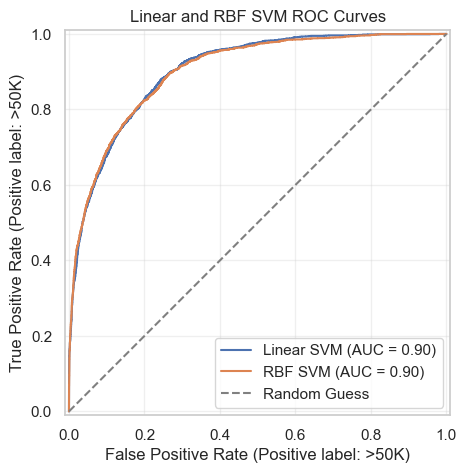

In [156]:
print("Linear")
print("Linear Accuracy:", np.mean(q31_accuracy_results), "+/-", np.std(q31_accuracy_results))
print("Linear F1:", np.mean(q31_f1_results), "+/-", np.std(q31_f1_results))
print("Linear ROC-AUC:", np.mean(q31_auc_results), "+/-", np.std(q31_auc_results))

print("RBF")
print("RBF Accuracy:", np.mean(q32_accuracy_results), "+/-", np.std(q32_accuracy_results))
print("RBF F1:", np.mean(q32_f1_results), "+/-", np.std(q32_f1_results))
print("RBF ROC-AUC:", np.mean(q32_auc_results), "+/-", np.std(q32_auc_results))
fig, ax = plt.subplots(figsize=(7, 5))

# Linear SVM ROC curve
RocCurveDisplay.from_estimator(
    linear_svm,
    X_val,
    y_val,
    pos_label=">50K",
    name="Linear SVM",
    ax=ax
)

# RBF SVM ROC curve
RocCurveDisplay.from_estimator(
    rbf_svm,
    X_val,
    y_val,
    pos_label=">50K",
    name="RBF SVM",
    ax=ax
)

# Random classifier
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)

ax.set_title("Linear and RBF SVM ROC Curves")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.show()

The RBF SVM achived a higher validation accuracy of $0.8546$ compared to the Linear SVM with $0.8528$, and a F1-score of $0.6566$ compared with $0.6560$. The SVM model had also a low standard deviation, meaning its performance was stable across the five folds. Looking at the plot we can see that both of the models performed almost equally as well. Overall the RBF kernel performed slightly better than the linear kernel.

### Q3.3

In [157]:
q33_results = []
c_values = [0.001, 0.01, 0.1, 1, 10, 100]

for c in c_values:
    q33_accuracy_results = []
    q33_f1_results = []
    q33_support_vector_results = []
    for fold, (train_index, _) in enumerate(stratified_cv.split(X_svm, y_svm)):
        X_fold_train = X_svm.iloc[train_index]
        y_fold_train = y_svm.iloc[train_index]

        c_svm = Pipeline([
            ("preprocessor", preprocessor),
            ("svm", SVC(kernel="rbf", C=c))
        ])

        # Train using the folds observations
        c_svm.fit(X_fold_train, y_fold_train)

        # Evaluate and predict
        y_val_pred = c_svm.predict(X_val)

        q33_accuracy_results.append(
            accuracy_score(y_val, y_val_pred)
        )

        q33_f1_results.append(
            f1_score(
                y_val,
                y_val_pred,
                pos_label=">50K"
            )
        )

        q33_support_vector_results.append(
            c_svm
            .named_steps["svm"]
            .n_support_
            .sum()
        )
    # Store results
    q33_results.append({
        "C": c,
        "Accuracy Mean":
            np.mean(q33_accuracy_results),
        "Accuracy Std":
            np.std(q33_accuracy_results),
        "F1 Mean":
            np.mean(q33_f1_results),
        "F1 Std":
            np.std(q33_f1_results),
        "Support Vectors Mean":
            np.mean(q33_support_vector_results)
    })

q33_results_df = pd.DataFrame(q33_results)

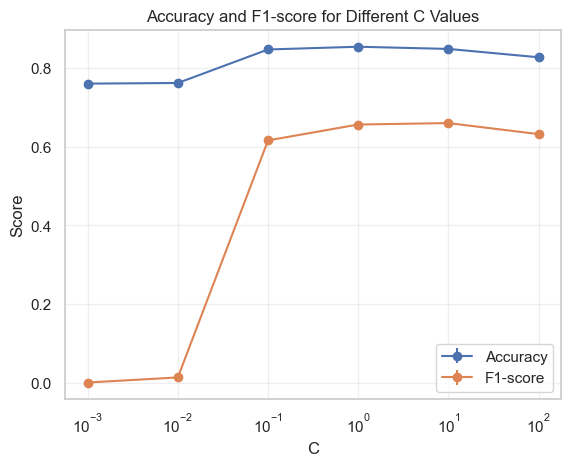

      C  Accuracy Mean  Accuracy Std  F1 Mean   F1 Std  Support Vectors Mean
  0.001       0.760749      0.000000 0.000000 0.000000                3833.0
  0.010       0.762305      0.001023 0.012888 0.008397                3851.4
  0.100       0.847645      0.001248 0.616205 0.004631                3318.8
  1.000       0.854627      0.000586 0.656630 0.002428                2951.4
 10.000       0.849038      0.001085 0.660286 0.003984                3000.4
100.000       0.827785      0.001335 0.632194 0.003972                2861.8


In [158]:
# Accuracy
plt.errorbar(
    q33_results_df["C"],
    q33_results_df["Accuracy Mean"],
    yerr=q33_results_df["Accuracy Std"],
    marker="o",
    label="Accuracy"
)

# F1-score
plt.errorbar(
    q33_results_df["C"],
    q33_results_df["F1 Mean"],
    yerr=q33_results_df["F1 Std"],
    marker="o",
    label="F1-score"
)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Score")
plt.title("Accuracy and F1-score for Different C Values")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

q33_results_df = pd.DataFrame(q33_results)
print(q33_results_df.to_string(index=False))

The performance improved as the C value increased. The highest accuracy was $0.854627$ achieved at $C=1$, while the highest F1 score was $0.660286$ achieved at $C=10$. I believe that $C=10$ is the best value, because F1 accounts for performance on the minority class, which is important for this imbalanced dataset.

Small C values use stronger regularization and create a wider margin, causing the model to underfit. As C increased, the margin became narrower and the number of support vectors generally decreased. However at $C=100$, both accuracy and F1-score decreased, suggesting that the model began to overfit.

### Q3.4

In [159]:
q34_results = []
gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]

for gamma in gamma_values:
    gamma_svm = Pipeline([
        ("preprocessor", preprocessor),
        ("svm", SVC(kernel="rbf", C=10, gamma=gamma))
    ])

    # Train on the entire SVM subsample
    gamma_svm.fit(X_svm, y_svm)

    # Evaluate on the validation set
    y_val_pred = gamma_svm.predict(X_val)

    q34_results.append({
        "Gamma": gamma,
        "Validation Accuracy": accuracy_score(
            y_val,
            y_val_pred
        ),
        "Validation F1": f1_score(
            y_val,
            y_val_pred,
            pos_label=">50K"
        ),
        "support vectors": (
            gamma_svm
            .named_steps["svm"]
            .n_support_
            .sum()
        )
    })

q34_results_df = pd.DataFrame(q34_results)
print(q34_results_df.to_string(index=False))

  Gamma  Validation Accuracy  Validation F1  support vectors
  0.001             0.850635       0.645099             3729
  0.010             0.855344       0.658943             3464
  0.100             0.845209       0.656520             3794
  1.000             0.790438       0.439024             8231
 10.000             0.765152       0.148478             9807
100.000             0.759930       0.023324             9988


The best gamma value to use out of the 6 tested was $0.010$, it achieved the best validation accuracy of $0.855344$, validation F1 of $0.658943$ and used the fewest support vectors, $3464$.

At $\text{gamma}=0.001$ the smoother boundary may have had higher bias, it used $3,729$ support vectors. At $\text{gamma}=0.1$, the scores fell slightly and the support vector increased to $3,794$. At $\text{gamma}$, $10$, and $100$, the scores decreased as the amount of support vector were used. This suggests that larger gamma values made the boundary too sensitive to individual training observations, increasing variance.

## Exercsie 4: Model Xomparison

### Q4.1

        Model  CV Accuracy  CV Accuracy Std    CV F1  CV F1 Std  CV ROC-AUC  CV ROC-AUC Std  Val Accuracy   Val F1  Val ROC-AUC
Decision Tree     0.856509         0.003689 0.657302   0.010980    0.902780        0.002446      0.862408 0.672355     0.907595
          SVM     0.847700         0.005627 0.646430   0.018249    0.902669        0.006786      0.855344 0.658943     0.906684


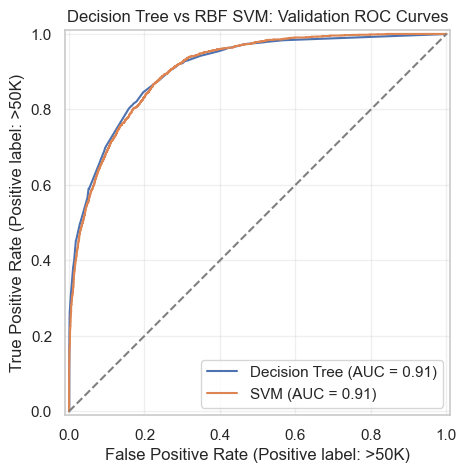

In [160]:
from sklearn.base import clone

q41_models = {
    "Decision Tree": (
        Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("decision_tree", DecisionTreeClassifier(
                random_state=42,
                ccp_alpha=0.0001,
                max_depth=9
            ))
        ]),
        X_train,
        y_train
    ),
    "SVM": (
        Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("svm", SVC(kernel="rbf", C=10, gamma=0.01))
        ]),
        X_svm,
        y_svm
    )
}

q41_results = []
fig, ax = plt.subplots(figsize=(7, 5))

for name, (model, X_fit, y_fit) in q41_models.items():
    cv_results = cross_validate(
        model,
        X_fit,
        y_fit,
        cv=stratified_cv,
        scoring={
            "accuracy": "accuracy",
            "f1": f1_scorer,
            "auc": "roc_auc"
        }
    )

    model.fit(X_fit, y_fit)
    y_val_pred = model.predict(X_val)

    if name == "Decision Tree":
        positive_index = list(model.classes_).index(">50K")
        y_val_score = model.predict_proba(X_val)[:, positive_index]
    else:
        y_val_score = model.decision_function(X_val)

    q41_results.append({
        "Model": name,
        "CV Accuracy": cv_results["test_accuracy"].mean(),
        "CV Accuracy Std": cv_results["test_accuracy"].std(),
        "CV F1": cv_results["test_f1"].mean(),
        "CV F1 Std": cv_results["test_f1"].std(),
        "CV ROC-AUC": cv_results["test_auc"].mean(),
        "CV ROC-AUC Std": cv_results["test_auc"].std(),
        "Val Accuracy": accuracy_score(y_val, y_val_pred),
        "Val F1": f1_score(y_val, y_val_pred, pos_label=">50K"),
        "Val ROC-AUC": roc_auc_score(y_val == ">50K", y_val_score)
    })

    RocCurveDisplay.from_estimator(
        model,
        X_val,
        y_val,
        pos_label=">50K",
        name=name,
        ax=ax
    )

q41_results_df = pd.DataFrame(q41_results)
print(q41_results_df.to_string(index=False))

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("Decision Tree vs RBF SVM: Validation ROC Curves")
ax.grid(True, alpha=0.3)
plt.show()

The decision tree achieved higher cross validation accuracy and F1 score, than the SVM. Their cross validation ROC AUC values where almost identical $0.902780$ for the tree and $0.902669$ for the SVM. The tree also performed better on the validation set, with an accuracy of $0.862408$, F1-score $0.672355$, and ROC-AUC $0.907595$, compared with $0.855344$, $0.658943$, and $0.906684$ for the SVM. Both the models performed very similar, but the decision tree had higher scores, so the decision tree generalize better.

### Q4.2

In [161]:
from sklearn.metrics import fbeta_score, precision_score, recall_score

q42_results = []

for name, (model, _, _) in q41_models.items():
    y_pred = model.predict(X_val)

    q42_results.append({
        "Model": name,
        "Precision": precision_score(y_val, y_pred, pos_label=">50K"),
        "Recall": recall_score(y_val, y_pred, pos_label=">50K"),
        "F0.5": fbeta_score(y_val, y_pred, beta=0.5, pos_label=">50K"),
        "F2": fbeta_score(y_val, y_pred, beta=2, pos_label=">50K")
    })

print(pd.DataFrame(q42_results).to_string(index=False))

        Model  Precision   Recall     F0.5       F2
Decision Tree   0.781303 0.590073 0.733745 0.620445
          SVM   0.755814 0.584082 0.713837 0.611888


The SVM can model complex patterns but its predictions are harder to explain and require comparisons with support vectors. The Desicion tree follows feature splits which are easier to inspect. The decision tree also achieved a higher validation accuracy and their ROC AUC score where nearly identical. I would therefor recommend the bank to use the decision tree, because it had better validation and performance.

I choose to use $F_{0.5}$ since it emphasizes precision and $F_2$ emphasizes recall. A false positive could make the bank give an unaffordable loan to a person and the tree had a higher $F_{0.5}$ $0.733745$ while the SVM had $0.713837$. While for a false negative the system could reject a real applicant, and the tree had a higher $F_2$.

### Q4.3

In [162]:
from sklearn.model_selection import GridSearchCV

tree_search = GridSearchCV(
    Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("decision_tree", DecisionTreeClassifier(random_state=42))
    ]),
    param_grid={
        "decision_tree__max_depth": [8, 10, 12],
        "decision_tree__min_samples_leaf": [1, 20, 100],
        "decision_tree__ccp_alpha": [0.0, 0.0001, 0.0005]
    },
    scoring=f1_scorer,
    cv=stratified_cv,
    n_jobs=-1
)
tree_search.fit(X_train, y_train)

svm_search = GridSearchCV(
    Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("svm", SVC(kernel="rbf"))
    ]),
    param_grid={
        "svm__C": [1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1]
    },
    scoring=f1_scorer,
    cv=stratified_cv,
    n_jobs=-1
)
svm_search.fit(X_svm, y_svm)

q43_results = []

for name, search in [
    ("Decision Tree", tree_search),
    ("SVM", svm_search)
]:
    model = search.best_estimator_
    y_pred = model.predict(X_val)

    q43_results.append({
        "Model": name,
        "Best settings": search.best_params_,
        "CV F1": search.best_score_,
        "Val Accuracy": accuracy_score(y_val, y_pred),
        "Val F1": f1_score(y_val, y_pred, pos_label=">50K")
    })

q43_results_df = pd.DataFrame(q43_results)
print(q43_results_df.to_string(index=False))

        Model                                                                                              Best settings    CV F1  Val Accuracy   Val F1
Decision Tree {'decision_tree__ccp_alpha': 0.0001, 'decision_tree__max_depth': 12, 'decision_tree__min_samples_leaf': 1} 0.674271      0.861998 0.694054
          SVM                                                                           {'svm__C': 1, 'svm__gamma': 0.1} 0.652076      0.855651 0.661546


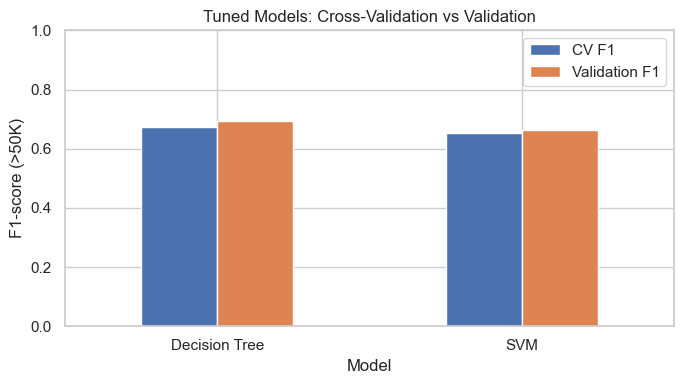

In [163]:
plot_df = q43_results_df.set_index("Model")[["CV F1", "Val F1"]]

plot_df.plot.bar(figsize=(7, 4), rot=0)
plt.ylabel("F1-score (>50K)")
plt.title("Tuned Models: Cross-Validation vs Validation")
plt.ylim(0, 1)
plt.legend(["CV F1", "Validation F1"])
plt.tight_layout()
plt.show()

These where the best settings to use for the models:
 - Decision: Tree decision_tree__ccp_alpha: 0.0001, decision_tree__max_depth: 12, decision_tree__min_samples_leaf: 1
 - SVM: svm__C: 1, svm__gamm: 0.1

The plot shows that the decision tree had a higher F1 score than the SVM in both cross validation and validation. It was therefore the better choice based on F1-score.

### 4.4

In [164]:
q44_results = []

for name, search in [
    ("Decision Tree", tree_search),
    ("SVM", svm_search)
]:
    model = search.best_estimator_

    y_test_pred = model.predict(X_test)

    if name == "Decision Tree":
        y_test_score = model.predict_proba(X_test)[:, list(model.classes_).index(">50K")]
    else:
        y_test_score = model.decision_function(X_test)

    q44_results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test F1": f1_score(y_test, y_test_pred, pos_label=">50K"),
        "Test ROC-AUC": roc_auc_score(y_test == ">50K", y_test_score)
    })

q44_results_df = pd.DataFrame(q44_results)
print(q44_results_df.to_string(index=False))

        Model  Test Accuracy  Test F1  Test ROC-AUC
Decision Tree       0.857918 0.683827      0.904553
      RBF SVM       0.860375 0.671167      0.900719


On the test set the SVM achieved a test accuracy of 0.860375 while the decision tree achieved a lower score of 0.857918. However, the decision tree had a higher F1 score, and 0.683826 versus 0.671167, and ROC AUC score 0.904553 versus 0.900719. This mostly matches the vladition results, where the decision tree also had the higher F1 score. The difference is that the SVM had a better accuracy on the test set, while the decision tree had a higher accuracy on the validation set.

### 4.5

A linear SVM draws one flat boundary to separate people who earn more than $50K from those who do not. Each feature is a direction in the data space. This can be difficult for the dataset because it mixes numerical features with one-hot encoded categories, and some of the features are also related to each other. The two income groups can overlap, and the effect of one feature may depend on another. For example, working more hours could mean different things for different occupations. One flat boundary may therefore miss some of these patterns in the dataset.

The RBF kernel lets the SVM create a more flexible boundary based on how similar the observations are. Instead of one flat boundary, the boundary can curve around groups of observations. This can help capture patterns that the linear SVM misses. The resulting decision boundary can therefore be curved and irregular rather than one flat plane, making to capture the relations with the features and then predicting a person income.

## Exercise 5: Advanced Decision Boundary Analysis

### Q5.1

PC1: 0.148679039144718
PC2: 0.10727308682563105
Total: 0.25595212597034905


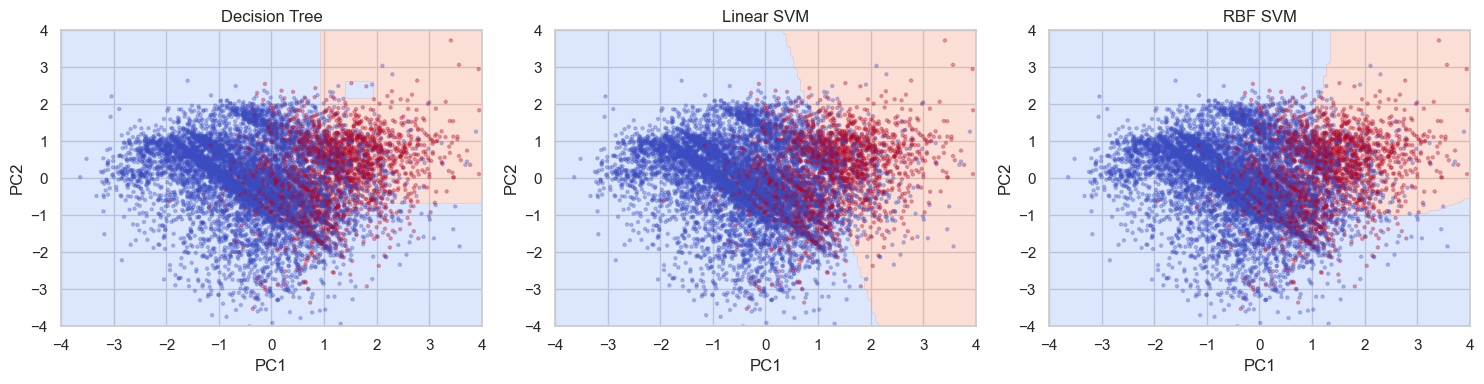

In [175]:
from sklearn.decomposition import PCA

prep = clone(preprocessor)
X_train_p = prep.fit_transform(X_train)
X_svm_p = prep.transform(X_svm)
X_val_p = prep.transform(X_val)

# Converts the data to dense arrays for PCA
if hasattr(X_train_p, "toarray"):
    X_train_p = X_train_p.toarray()
    X_svm_p = X_svm_p.toarray()
    X_val_p = X_val_p.toarray()

# Reduce the data into two dimenson
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_p)
X_svm_2d = pca.transform(X_svm_p)
X_val_2d = pca.transform(X_val_p)

print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total:", pca.explained_variance_ratio_.sum())

# Use the best model settings
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=1,
        ccp_alpha=0.0001, random_state=42
    ),
    "Linear SVM": SVC(kernel="linear", C=1),
    "RBF SVM": SVC(kernel="rbf", C=1, gamma=0.1)
}

# Plot
x_min, x_max = -4, 4
y_min, y_max = -4, 4
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120), np.linspace(y_min, y_max, 120))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    X_fit, y_fit = (
        (X_train_2d, y_train) if name == "Decision Tree"
        else (X_svm_2d, y_svm)
    )
    model.fit(X_fit, y_fit)

    boundary = (model.predict(grid) == ">50K").astype(int).reshape(xx.shape)
    ax.contourf(xx, yy, boundary, levels=[-0.5, 0.5, 1.5],
                cmap="coolwarm", alpha=0.3)
    ax.scatter(X_val_2d[:, 0], X_val_2d[:, 1],
               c=(y_val == ">50K").astype(int),
               cmap="coolwarm", s=5, alpha=0.3)
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max),
           title=name, xlabel="PC1", ylabel="PC2")

plt.tight_layout()
plt.show()

The PCA reduced the training data into two components, PC1 explained $14.87\%$ of the variance and PC2 explained $10.72\%$, for a total of $25.6\%$. I retrained the decision tree, linear SVM and RBF SVM on these two components. The three plots shows their decision boundaries.

### Q5.2

**Decision tree**
- The Decision tree has a boundary made of horizontal and vertical lines. It looks like steps because the tree splits on one PCA component at a time and this gives it a piecewise boundary made of rectangular areas.

**Linear SVM**
- The linear SVM creates a single straight boundary to separate the two classes.

**RBF SVM**
- The RBF SVM has a smooth, curved boundary. It can bend around groups of points because it uses similarity between observations to separate the classes.

### Q5.3

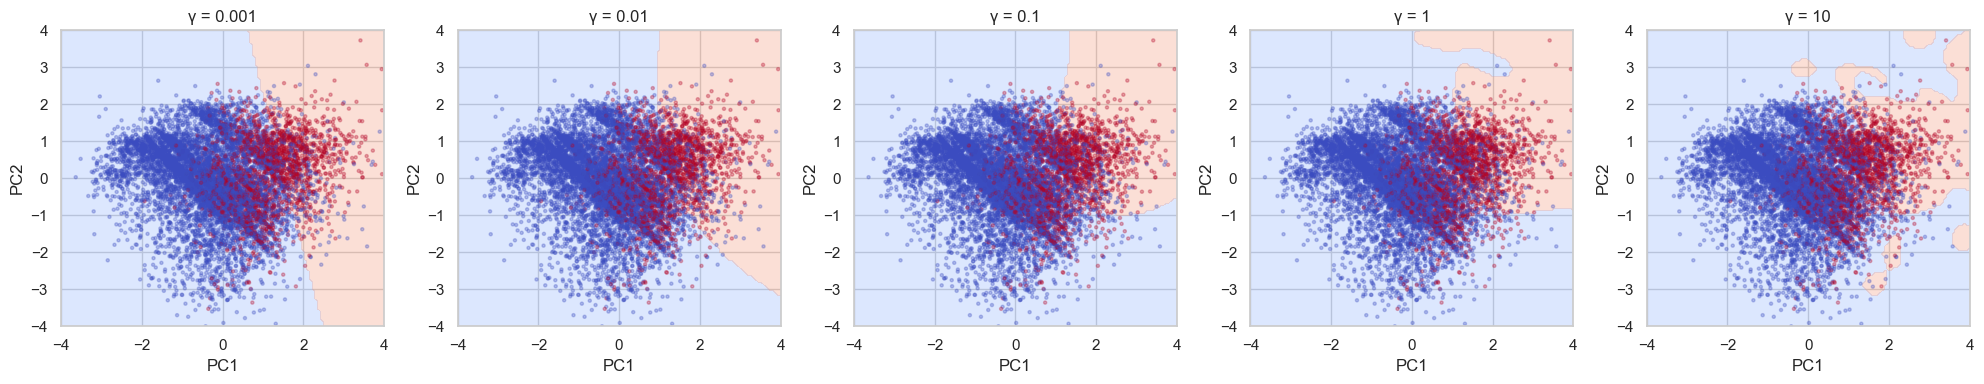

 Gamma  Support Vectors  Train F1   Val F1
 0.001             4512  0.452546 0.466765
 0.010             4212  0.511503 0.526431
 0.100             3954  0.518755 0.537338
 1.000             4025  0.543009 0.558778
10.000             5177  0.579024 0.570794


In [176]:
gamma_values = [0.001, 0.01, 0.1, 1, 10]
q53_results = []

fig, axes = plt.subplots(1, len(gamma_values), figsize=(20, 4))

for ax, gamma in zip(axes, gamma_values):
    model = SVC(kernel="rbf", C=1, gamma=gamma)
    model.fit(X_svm_2d, y_svm)

    # Store results for the written discussion
    q53_results.append({
        "Gamma": gamma,
        "Support Vectors": model.n_support_.sum(),
        "Train F1": f1_score(
            y_svm, model.predict(X_svm_2d), pos_label=">50K"
        ),
        "Val F1": f1_score(
            y_val, model.predict(X_val_2d), pos_label=">50K"
        )
    })

    # Draw the decision boundary
    boundary = (model.predict(grid) == ">50K").astype(int).reshape(xx.shape)
    ax.contourf(xx, yy, boundary, levels=[-0.5, 0.5, 1.5],
                cmap="coolwarm", alpha=0.3)
    ax.scatter(X_val_2d[:, 0], X_val_2d[:, 1],
               c=(y_val == ">50K").astype(int),
               cmap="coolwarm", s=5, alpha=0.3)
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max),
           title=f"γ = {gamma}", xlabel="PC1", ylabel="PC2")

plt.tight_layout()
plt.show()

q53_results_df = pd.DataFrame(q53_results)
print(q53_results_df.to_string(index=False))

At gamma equal to 0.001 the boundary is smooth and almost linear and the F1 score validation  score is $0.466765$, which suggest the model is underfitting. As the gamma increases the boundary bends more around the data and the validation F1 score improves and reaches $0.570794$ at gamme equal to 10. The number of support vectors falls from 4512 at gamma=0.001 to 3954 at gamme=0.1 and then begins to rise to 5177 at gamme 10. At Gamma 10  the plot shows small irregular regions which suggest the model is at risk for overfitting.

### Q5.4

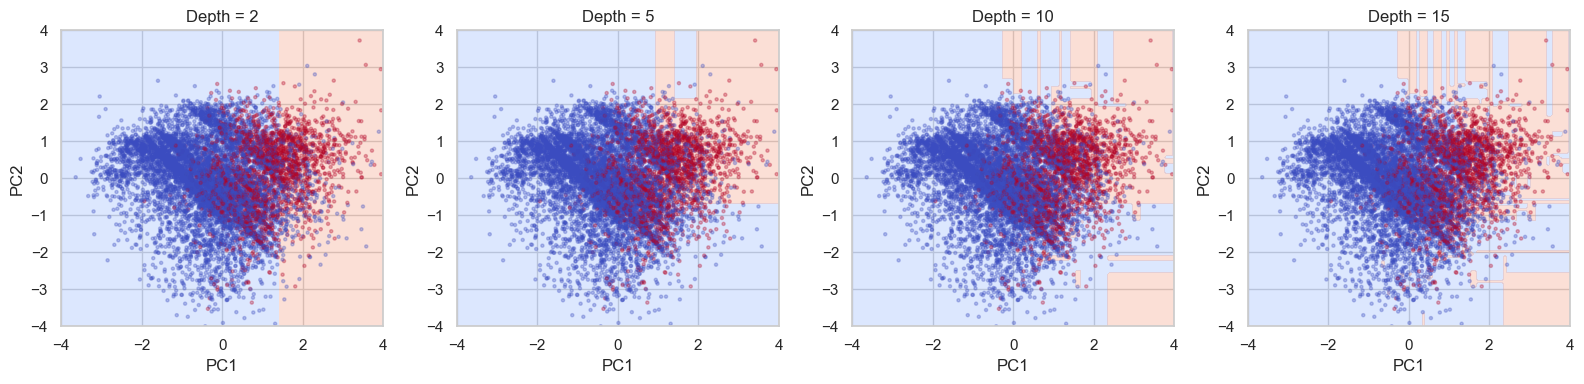

 Max Depth  Train F1   Val F1
         2  0.465315 0.462695
         5  0.567930 0.556539
        10  0.602381 0.538481
        15  0.730834 0.539388


In [178]:
depth_values = [2, 5, 10, 15]
q54_results = []

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, depth in zip(axes, depth_values):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_2d, y_train)

    q54_results.append({
        "Max Depth": depth,
        "Train F1": f1_score(
            y_train, model.predict(X_train_2d), pos_label=">50K"
        ),
        "Val F1": f1_score(
            y_val, model.predict(X_val_2d), pos_label=">50K"
        )
    })

    boundary = (model.predict(grid) == ">50K").astype(int).reshape(xx.shape)
    ax.contourf(xx, yy, boundary, levels=[-0.5, 0.5, 1.5],
                cmap="coolwarm", alpha=0.3)
    ax.scatter(X_val_2d[:, 0], X_val_2d[:, 1],
               c=(y_val == ">50K").astype(int),
               cmap="coolwarm", s=5, alpha=0.3)
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max),
           title=f"Depth = {depth}", xlabel="PC1", ylabel="PC2")

plt.tight_layout()
plt.show()

q54_results_df = pd.DataFrame(q54_results)
print(q54_results_df.to_string(index=False))

The higher th depth is the more splits the decision tree creates and smaller recatangular regions. At depth 2 the boundary is simple and both training F1 and validaition F1 are low suggesting the model is underfitting. At depth five the train and validation F1 improves.

At depth 10 and 15 the boundary becomes more detailed. Training F1 rises to 0.73084 at depth 15 but the validation F1 is only 0.539388. The gap between the validation and training suggest it is overfitting. This is similar to exercise 2, when a shallow tree has a simple boundary and can miss patterns in the data, which is called high bias. As the tree gets deeper, it finds more patterns. But a very deep tree can also fit details that only occur in the training data, which increases variance. Here, training F1 keeps improving, while validation F1 is lower at depth 15 than at depth 5.

### Q5.5

The first two PCA components explain about 25.6% of the variance, so the 2D plots leave out much of the information in the original data. They help us see how the three models behave when trained on only two components, such as whether their boundaries are straight, stepped or curved. But they do not show the exact boundaries of the models trained on all features, and we cannot use them to judge those models full performance.

A partial dependence plot could complement this analysis. For example, it could show how the full model’s predictions change with age and hours worked while averaging over the other features. This would help us examine the original model without reducing it to two PCA components.